# Importing Libraries and functions

In [1]:
import pandas as pd
import numpy as np

# To save and load our models
import pickle

# To plot 
import matplotlib.pyplot as plt
import seaborn  as sns

# To training the model
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble        import RandomForestClassifier
from xgboost import XGBClassifier

# Explainability
import shap
from sklearn.inspection import permutation_importance

# Fairlearn 
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio
from fairlearn.metrics import equalized_odds_difference,  equalized_odds_ratio
from fairlearn.metrics import selection_rate, true_negative_rate, true_positive_rate, false_positive_rate, false_negative_rate
from fairlearn.metrics import MetricFrame

# Personalized functions
from functions import compute_metrics, fpr, fnr, tmo

# Importing the data

In [2]:
df_trainval = pd.read_csv('CSV_TRAIN.csv', sep = ";")
df_test     = pd.read_csv('CSV_TEST.csv',  sep = ";")

df_trainval['TARGET'] = 1 - df_trainval["DEFAULT"]
df_test['TARGET']     = 1 - df_test["DEFAULT"]

In [3]:
df_trainval_nonulls = df_trainval.dropna().reset_index(drop=True)
df_test_nonulls     = df_test.dropna().reset_index(drop=True)

In [4]:
X_trainval   = df_trainval_nonulls.drop(['DEFAULT','TARGET'], axis = 1)
Y_trainval   = df_trainval_nonulls['TARGET']

X_train, X_val, Y_train, Y_val = train_test_split(X_trainval, Y_trainval, test_size = 0.25, random_state = 1)

X_test   = df_test_nonulls.drop(['DEFAULT','TARGET'], axis = 1)
Y_test   = df_test_nonulls['TARGET']


PF1_train = X_train['PF1']
PF2_train = X_train['PF2']

PF1_val   = X_val['PF1']
PF2_val   = X_val['PF2']

PF1_test  = X_test['PF1']
PF2_test = X_test['PF2']

X_train = X_train.drop(['PF1', 'PF2'], axis = 1)
X_val   = X_val.drop(['PF1', 'PF2'], axis = 1)
X_test  = X_test.drop(['PF1', 'PF2'], axis = 1)

# Load the base model

In [5]:
base_xgb = pickle.load(open('./modelXGB_base.cls', "rb"))

The goal of this notebook is to reduce the bias detected in the base model using the post-processing technique ROC (Reject Option based Clasification) 

# Deciding the optimal epsilon

We will iterate over some epsilons. We will then analyze the trade-off between fairness and profitability and choose an epsilon that provides the better gain in fairness while minimizing profitability loss.

We start by computing the best threshold based on the <5% default rate, maximum acceptance rate criteria.

In [6]:
thresholds = np.linspace(0.7, 1, 250)

rows = []

for t in thresholds:
    resultado = compute_metrics(X_val, Y_val, base_xgb, t)
    rows.append(resultado)

df_metricas = pd.DataFrame(rows, columns=['Threshold', 'TMO', 'approvalRate', 'Recall', 'Precision', 'FPR', 'FNR'])

In [7]:
df_metricas_filtered = df_metricas.sort_values('approvalRate', ascending=False)
df_metricas_filtered = df_metricas_filtered[df_metricas_filtered['TMO']< 0.05]
df_metricas_filtered.head()

,Threshold,TMO,approvalRate,Recall,Precision,FPR,FNR
165,0.898795,0.049122,0.556909,0.592493,0.950878,0.257519,0.407507
166,0.900000,0.047636,0.549121,0.585121,0.952364,0.246241,0.414879
167,0.901205,0.046829,0.541534,0.577525,0.953171,0.238722,0.422475
168,0.902410,0.047103,0.534145,0.569482,0.952897,0.236842,0.430518
169,0.903614,0.046899,0.527955,0.563003,0.953101,0.233083,0.436997


In [8]:
best_threshold = df_metricas_filtered.iloc[0,0]

Once we have the optimal threshold, we will create an indecision zone near that threshold using a parameter we will call epsilon. In that gray zone, we will accept those belonging to the protected group and reject those belonging to the privileged group.

In [9]:
metrics = {
    "Default Rate": tmo,
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "Selection_rate": selection_rate,
    "FPR": false_positive_rate,
    "FNR": false_negative_rate,
    "Specificity": true_negative_rate
}

In [10]:
epsilons = np.linspace(0, 0.025, 25)
columns_summary = ["Epsilon",
                    "Default_rate_general", "Accuracy_general", "Precision_general",
                    "Recall_general", "Selection_rate_general", "FPR_general", 
                    "FNR_general", "Specificity_general",
                       "Default_rate_ratio",
                       "Accuracy_ratio", "Precision_ratio",
                    "Recall_ratio", "Selection_rate_ratio", "FPR_ratio", 
                    "FNR_ratio", "Specificity_ratio"
                      ]
rows = []
for epsilon in epsilons:
    
    print(f"Computing performance metrics and fairness ratios for epsilon:{epsilon}")
    
    prob_val   = base_xgb.predict_proba(X_val)[:, 1]
    pred_adj_val = np.where(
            PF2_val == 0,
            (prob_val >= best_threshold + epsilon), # Those belonging to the privileged class are required to have an score of threshold + epsilon 
                                                    # to be approved the loan
            (prob_val >= best_threshold - epsilon)  # while does belonging to the privileged class are approved the loan if its score
                                                    # sits above threshold - epsilon
        ).astype(int)
    
    
    mf = MetricFrame(
            metrics=metrics,
            y_true= Y_val,
            y_pred= pred_adj_val,
            sensitive_features= PF2_val
        )
    try:
        performance_metrics = mf.overall.tolist()
        fairness_ratios = mf.ratio().tolist()
        observation = [epsilon] + performance_metrics + fairness_ratios
        rows.append(observation)
    except:
        print(f"No s'ha pogut afegir l'observació corresponent a epsilon: {epsilon}")
        i = i + 1


df_metricas = pd.DataFrame(rows, columns = columns_summary)

Computing performance metrics and fairness ratios for epsilon:0.0
Computing performance metrics and fairness ratios for epsilon:0.0010416666666666667
Computing performance metrics and fairness ratios for epsilon:0.0020833333333333333
Computing performance metrics and fairness ratios for epsilon:0.003125
Computing performance metrics and fairness ratios for epsilon:0.004166666666666667
Computing performance metrics and fairness ratios for epsilon:0.005208333333333333
Computing performance metrics and fairness ratios for epsilon:0.00625
Computing performance metrics and fairness ratios for epsilon:0.007291666666666667
Computing performance metrics and fairness ratios for epsilon:0.008333333333333333
Computing performance metrics and fairness ratios for epsilon:0.009375
Computing performance metrics and fairness ratios for epsilon:0.010416666666666666
Computing performance metrics and fairness ratios for epsilon:0.011458333333333333
Computing performance metrics and fairness ratios for ep

In [11]:
df_metricas.head(n=25)

,Epsilon,Default_rate_general,Accuracy_general,Precision_general,Recall_general,Selection_rate_general,FPR_general,FNR_general,Specificity_general,Default_rate_ratio,Accuracy_ratio,Precision_ratio,Recall_ratio,Selection_rate_ratio,FPR_ratio,FNR_ratio,Specificity_ratio
0,0.000000,0.049122,0.608427,0.950878,0.592493,0.556909,0.257519,0.407507,0.742481,0.988152,0.821496,0.999386,0.757585,0.726732,0.513936,0.685867,0.802779
1,0.001042,0.047825,0.608427,0.952175,0.591600,0.555312,0.250000,0.408400,0.750000,0.952680,0.828617,0.997547,0.768473,0.739444,0.555481,0.699412,0.828520
2,0.002083,0.047704,0.609824,0.952296,0.593164,0.556709,0.250000,0.406836,0.750000,0.943619,0.843593,0.997068,0.786644,0.757292,0.574352,0.719227,0.836889
3,0.003125,0.047825,0.608427,0.952175,0.591600,0.555312,0.250000,0.408400,0.750000,0.938786,0.862431,0.996799,0.808709,0.778744,0.593662,0.747090,0.845338
4,0.004167,0.047067,0.605831,0.952933,0.588025,0.551518,0.244361,0.411975,0.755639,0.925861,0.876926,0.996156,0.825869,0.795781,0.615119,0.770886,0.858616
5,0.005208,0.047153,0.604832,0.952847,0.586908,0.550519,0.244361,0.413092,0.755639,0.943416,0.891776,0.997096,0.842322,0.810870,0.615119,0.791829,0.858616
6,0.006250,0.047411,0.601837,0.952589,0.583557,0.547524,0.244361,0.416443,0.755639,0.904892,0.906526,0.994965,0.861260,0.830876,0.657129,0.817511,0.875889
7,0.007292,0.047235,0.600040,0.952765,0.581323,0.545327,0.242481,0.418677,0.757519,0.882888,0.919957,0.993736,0.878088,0.848158,0.687516,0.839776,0.889143
8,0.008333,0.046640,0.599241,0.953360,0.579982,0.543730,0.238722,0.420018,0.761278,0.876957,0.933746,0.993484,0.894616,0.864342,0.705373,0.861188,0.898125
9,0.009375,0.046074,0.598043,0.953926,0.578195,0.541733,0.234962,0.421805,0.765038,0.845700,0.948758,0.991767,0.914077,0.884673,0.748649,0.886626,0.916065


By looking at the values of distinct fairness ratios and performances stats, we choose 0.014583 as the epsilon which suits the best our goal. If we wanted to maximize a particular ratio, we could do some plots to analyze the trade-offs that take place between performance and that particular ratio for different epsilons. We have selected an epsilon that 

In [12]:
best_epsilon = 0.014583333333333334

In [13]:
df_metricas[df_metricas["Epsilon"] == best_epsilon]

,Epsilon,Default_rate_general,Accuracy_general,Precision_general,Recall_general,Selection_rate_general,FPR_general,FNR_general,Specificity_general,Default_rate_ratio,Accuracy_ratio,Precision_ratio,Recall_ratio,Selection_rate_ratio,FPR_ratio,FNR_ratio,Specificity_ratio
14,0.014583,0.045455,0.589457,0.954545,0.567694,0.53155,0.227444,0.432306,0.772556,0.784099,0.96595,0.98823,0.979341,0.991787,0.905229,0.972812,0.971209


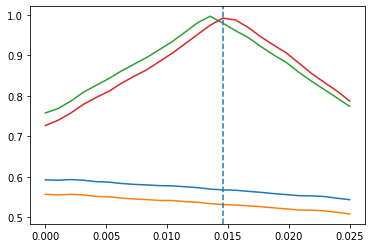

In [14]:
plt.plot(df_metricas["Epsilon"], df_metricas["Recall_general"])
plt.plot(df_metricas["Epsilon"], df_metricas["Selection_rate_general"])

plt.plot(df_metricas["Epsilon"], df_metricas["Recall_ratio"])
plt.plot(df_metricas["Epsilon"], df_metricas["Selection_rate_ratio"])

plt.axvline(x=best_epsilon, linestyle='--')

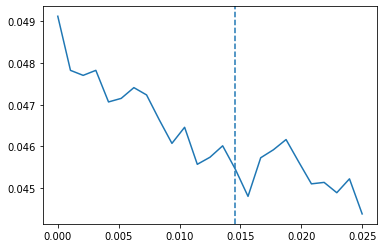

In [15]:
plt.plot(df_metricas["Epsilon"], df_metricas["Default_rate_general"])
plt.axvline(x=best_epsilon, linestyle='--')

# Performance on test data

In [16]:
prob_test     = base_xgb.predict_proba(X_test)[:, 1]
pred_adj_test = np.where(
            PF2_test == 0,
            (prob_test >= best_threshold + best_epsilon), # Those belonging to the privileged class are required to have an score of threshold + epsilon 
                                                          # to be approved the loan
            (prob_test >= best_threshold - best_epsilon)        # while does belonging to the privileged class are approved the loan if its score
                                                          # sits above threshold - epsilon
        ).astype(int)

metrics = {
    "N": lambda y_true, y_pred: len(y_true),
    "Default_Rate": tmo,
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "Selection_rate": selection_rate,
    "FPR": false_positive_rate,
    "FNR": false_negative_rate,
    "Specificity": true_negative_rate
}

mf1 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred= pred_adj_test,
    sensitive_features= PF1_test
)

mf2 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred= pred_adj_test,
    sensitive_features= PF2_test
)

intersectional_fairness = pd.DataFrame({"PF1": PF1_test, "PF2": PF2_test})

mf12 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred= pred_adj_test,
    sensitive_features= intersectional_fairness
)

In [17]:
mf1.overall

N                      5726
Default_Rate      0.0522293
Accuracy           0.599546
Precision          0.947771
Recall             0.582958
Selection_rate     0.548376
FPR                 0.26409
FNR                0.417042
Specificity         0.73591
dtype: object

# Fairness Metrics

Fairness Metrics grouped by Protected Feature 1

In [18]:
mf1.by_group.head()

,N,Default_Rate,Accuracy,Precision,Recall,Selection_rate,FPR,FNR,Specificity
PF1,,,,,,,,,
0,2522,0.0470935,0.585646,0.952907,0.568981,0.538858,0.260163,0.431019,0.739837
1,3204,0.0561482,0.610487,0.943852,0.594203,0.555868,0.266667,0.405797,0.733333


In [19]:
mf1.ratio()

N                 0.787141
Default_Rate      0.838734
Accuracy           0.95931
Precision         0.990498
Recall            0.957553
Selection_rate      0.9694
FPR                0.97561
FNR               0.941482
Specificity       0.991209
dtype: object

Fairness Metrics grouped by Protected Feature 2

In [20]:
mf2.by_group.head()

,N,Default_Rate,Accuracy,Precision,Recall,Selection_rate,FPR,FNR,Specificity
PF2,,,,,,,,,
0,3484,0.0483619,0.596441,0.951638,0.582246,0.551952,0.272727,0.417754,0.727273
1,2242,0.0583402,0.604371,0.94166,0.584098,0.542819,0.253571,0.415902,0.746429


In [21]:
mf2.ratio()

N                 0.643513
Default_Rate      0.828964
Accuracy          0.986879
Precision         0.989515
Recall             0.99683
Selection_rate    0.983454
FPR               0.929762
FNR               0.995568
Specificity       0.974337
dtype: object

Fairness Metrics grouped by the intersections of both protected features

In [22]:
mf12.by_group.head()

N Default_Rate  Accuracy Precision    Recall Selection_rate  \
PF1 PF2                                                                   
0   0    1609     0.045819  0.579863  0.954181  0.567052       0.542573   
    1     913    0.0493827  0.595838  0.950617  0.572491       0.532311   
1   0    1875    0.0504762  0.610667  0.949524  0.595579           0.56   
    1    1329    0.0642955  0.610233  0.935705  0.592208       0.550038   

              FPR       FNR Specificity  
PF1 PF2                                  
0   0    0.285714  0.432948    0.714286  
    1    0.226415  0.427509    0.773585  
1   0    0.263682  0.404421    0.736318  
    1    0.270115  0.407792    0.729885

In [23]:
mf12.ratio()

N                 0.486933
Default_Rate      0.712632
Accuracy          0.949558
Precision         0.980636
Recall            0.952102
Selection_rate    0.950555
FPR               0.792453
FNR                0.93411
Specificity       0.923345
dtype: object